In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    MinMaxScaler,
    PowerTransformer,
)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.linear_model import LogisticRegression


from imblearn.under_sampling import RandomUnderSampler


import joblib


from src.config import (
    CLUSTERED_DATA,
    FINAL_MODEL_FILEPATH
)
from src.models import (
    construct_pipeline,
    get_cv_results,
    organize_results
)
from src.graphics import (
    compare_metrics
)

In [2]:
df = pd.read_parquet(CLUSTERED_DATA)
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Age,MntTotal,MntRegularProds,Children,hasChildren,AcceptedCmpTotal,HasAcceptedCmp,NumPurchasesTotal,AgeGroup,cluster
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,57,1617,1529,0,0,0,0,22,46-60,1
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,60,27,21,2,1,0,0,4,46-60,0
2,Graduation,Partner,71613.0,0,0,26,426,49,127,111,...,49,776,734,0,0,0,0,20,46-60,1
3,Graduation,Partner,26646.0,1,0,26,11,4,20,10,...,30,53,48,1,1,0,0,6,18-30,0
4,PhD,Partner,58293.0,1,0,94,173,43,118,46,...,33,422,407,1,1,0,0,14,31-45,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Education            2187 non-null   object  
 1   Marital_Status       2187 non-null   object  
 2   Income               2187 non-null   float64 
 3   Kidhome              2187 non-null   int64   
 4   Teenhome             2187 non-null   int64   
 5   Recency              2187 non-null   int64   
 6   MntWines             2187 non-null   int64   
 7   MntFruits            2187 non-null   int64   
 8   MntMeatProducts      2187 non-null   int64   
 9   MntFishProducts      2187 non-null   int64   
 10  MntSweetProducts     2187 non-null   int64   
 11  MntGoldProds         2187 non-null   int64   
 12  NumDealsPurchases    2187 non-null   int64   
 13  NumWebPurchases      2187 non-null   int64   
 14  NumCatalogPurchases  2187 non-null   int64   
 15  NumStorePurchases    

In [4]:
X = df.drop("Response", axis=1)
y = df["Response"]

In [5]:
# Definindo a transformação de cada coluna

min_max_columns = [
    "Recency",
    "DaysSinceEnrolled",
]

std_columns = [
    "Income",
    "Age",
]

power_columns = X.columns[
    X.columns.str.startswith("Mnt") |
    X.columns.str.startswith("Num")
].tolist()

one_hot_columns = X.columns.difference(
    min_max_columns + std_columns + power_columns
).tolist()

In [6]:
# Definição do pré-processamento das colunas
preprocessing = ColumnTransformer(
    [
        ("ohe", OneHotEncoder(drop="first"), one_hot_columns),
        ("std", StandardScaler(), std_columns),
        ("min_max", MinMaxScaler(), min_max_columns),
        ("power", PowerTransformer(), power_columns),
    ]
)

In [7]:
RANDOM_STATE = 42

In [8]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)

In [9]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [10]:
classificators = {
    "LogisticRegression": {
        "feat_selection": SelectKBest(f_classif, k=10),
        "resampler": rus,
        "preprocessing": preprocessing,
        "classificator": LogisticRegression(
            random_state=RANDOM_STATE
        ),
    },
}

In [11]:
pipeline = construct_pipeline(**classificators["LogisticRegression"])
pipeline.fit(X, y)

,steps,"[('preprocessing', ...), ('selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('std', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
pipeline[:-1].get_feature_names_out()

array(['ohe__AcceptedCmp1_1', 'ohe__AcceptedCmp3_1',
       'ohe__AcceptedCmp5_1', 'ohe__AcceptedCmpTotal_3',
       'ohe__HasAcceptedCmp_1', 'ohe__hasChildren_1',
       'power__MntMeatProducts', 'power__NumCatalogPurchases',
       'power__MntTotal', 'power__MntRegularProds'], dtype=object)

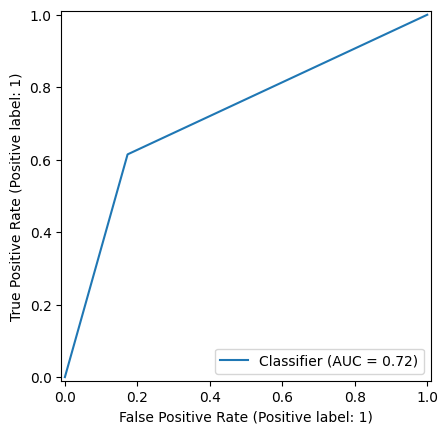

In [13]:
y_pred = cross_val_predict(
    pipeline,
    X, y,
    cv=kf,
    n_jobs=-1
)

roc = RocCurveDisplay.from_predictions(y, y_pred)

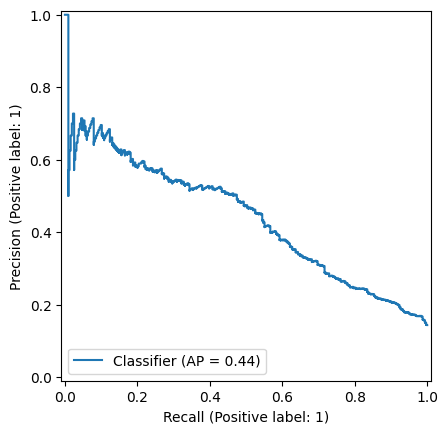

In [14]:
y_pred = cross_val_predict(
    pipeline,
    X, y,
    cv=kf,
    n_jobs=-1,
    method="decision_function"
)

prc = PrecisionRecallDisplay.from_predictions(y, y_pred)

In [15]:
pipeline.named_steps.keys()

dict_keys(['preprocessing', 'selector', 'sampler', 'clf'])

In [16]:
param_grid = {
    "selector__k": np.arange(10, 26, 5),
    "clf__C": np.logspace(-3, 3, 7),
    "clf__solver": ["liblinear", "lbfgs", "saga"],
    "clf__penalty": ["l1", "l2", "elasticnet", None],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring=[
        "roc_auc",
        "average_precision",
        "accuracy",
    ],
    refit="average_precision",
    n_jobs=-1,
)

grid_search.fit(X, y)

/home/lucas/Documentos/python/ifood_analyst/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/lucas/Documentos/python/ifood_analyst/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/lucas/Documentos/python/ifood_analyst/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/lucas/Documentos/python/ifood_analyst/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/lucas/Documentos/python/ifood_analyst/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__C': array([1.e-03...e+02, 1.e+03]), 'clf__penalty': ['l1', 'l2', ...], 'clf__solver': ['liblinear', 'lbfgs', ...], 'selector__k': array([10, 15, 20, 25])}"
,scoring,"['roc_auc', 'average_precision', ...]"
,n_jobs,-1
,refit,'average_precision'
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ohe', ...), ('std', ...), ...]"


In [17]:
grid_search.best_params_

{'clf__C': np.float64(10.0),
 'clf__penalty': 'l1',
 'clf__solver': 'liblinear',
 'selector__k': np.int64(25)}

In [18]:
grid_search.best_estimator_[:-1].get_feature_names_out()

array(['ohe__AcceptedCmp1_1', 'ohe__AcceptedCmp2_1',
       'ohe__AcceptedCmp3_1', 'ohe__AcceptedCmp4_1',
       'ohe__AcceptedCmp5_1', 'ohe__AcceptedCmpTotal_1',
       'ohe__AcceptedCmpTotal_2', 'ohe__AcceptedCmpTotal_3',
       'ohe__HasAcceptedCmp_1', 'ohe__Teenhome_1',
       'ohe__YearsSinceEnrolled_1', 'ohe__cluster_1',
       'ohe__hasChildren_1', 'std__Income', 'min_max__Recency',
       'min_max__DaysSinceEnrolled', 'power__MntWines',
       'power__MntFruits', 'power__MntMeatProducts',
       'power__MntGoldProds', 'power__NumWebPurchases',
       'power__NumCatalogPurchases', 'power__MntTotal',
       'power__MntRegularProds', 'power__NumPurchasesTotal'], dtype=object)

In [19]:
grid_search.best_score_

np.float64(0.629124881679392)

In [20]:
grid_search.cv_results_["params"][
    np.nanargmax(grid_search.cv_results_["mean_test_roc_auc"])
]

{'clf__C': np.float64(1.0),
 'clf__penalty': 'l2',
 'clf__solver': 'saga',
 'selector__k': np.int64(25)}

In [21]:
grid_search.cv_results_["params"][
    np.nanargmax(grid_search.cv_results_["mean_test_accuracy"])
]

{'clf__C': np.float64(0.001),
 'clf__penalty': 'l1',
 'clf__solver': 'liblinear',
 'selector__k': np.int64(10)}

In [22]:
df_results_gs = pd.DataFrame(
    {
        "auprc": grid_search.cv_results_["mean_test_average_precision"],
        "auroc": grid_search.cv_results_["mean_test_roc_auc"],
        "accuracy": grid_search.cv_results_["mean_test_accuracy"],
    }
)
df_results_gs.head()

,auprc,auroc,accuracy
0,0.143575,0.5,0.856425
1,0.143575,0.5,0.856425
2,0.143575,0.5,0.856425
3,0.143575,0.5,0.856425
4,NaN,NaN,NaN


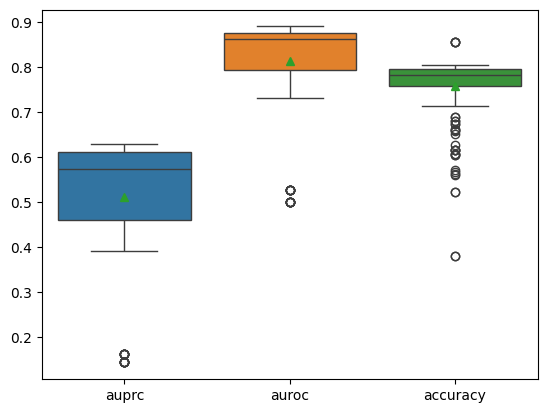

In [23]:
fig, ax = plt.subplots()

sns.boxplot(
    df_results_gs,
    showmeans=True,
    ax=ax,
)

plt.show()

In [24]:
classificators = {
    "DummyClassifier": {
        "feat_selection": None,
        "resampler": None,
        "preprocessing": None,
        "classificator": DummyClassifier(
            strategy="stratified",
            random_state=RANDOM_STATE
        ),
    },
    "LogisticRegression": {
        "feat_selection": SelectKBest(f_classif, k=10),
        "resampler": rus,
        "preprocessing": preprocessing,
        "classificator": LogisticRegression(
            random_state=RANDOM_STATE
        ),
    },
    "LogisticRegression_grid_search": {
        "feat_selection": grid_search.best_estimator_["selector"],
        "resampler": grid_search.best_estimator_["sampler"],
        "preprocessing": grid_search.best_estimator_["preprocessing"],
        "classificator": grid_search.best_estimator_["clf"]
    },
}

In [25]:
results = {
    name: get_cv_results(
        X, y, kf, **classificator
    ) for name, classificator in classificators.items()
}

In [26]:
df_results = organize_results(results)
df_results

,model,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision,total_time
0,DummyClassifier,0.002109,0.012293,0.760274,0.171875,0.174603,0.173228,0.516635,0.148731,0.014402
0,DummyClassifier,0.001773,0.009179,0.742009,0.109375,0.111111,0.110236,0.479556,0.140007,0.010952
0,DummyClassifier,0.001511,0.008082,0.748284,0.126984,0.126984,0.126984,0.489963,0.141983,0.009593
0,DummyClassifier,0.001362,0.008466,0.76659,0.190476,0.190476,0.190476,0.527056,0.152986,0.009828
0,DummyClassifier,0.001495,0.007571,0.75286,0.140625,0.145161,0.142857,0.499247,0.141695,0.009066
1,LogisticRegression,0.059905,0.035138,0.80137,0.390909,0.68254,0.49711,0.819386,0.45299,0.095043
1,LogisticRegression,0.088094,0.036715,0.828767,0.434783,0.634921,0.516129,0.827683,0.566214,0.124809
1,LogisticRegression,0.096147,0.034669,0.810069,0.4,0.634921,0.490798,0.816696,0.443145,0.130816
1,LogisticRegression,0.08812,0.034707,0.775744,0.315789,0.47619,0.379747,0.741109,0.377571,0.122827
1,LogisticRegression,0.088445,0.034117,0.76659,0.333333,0.645161,0.43956,0.786882,0.466337,0.122562


In [27]:
df_results.groupby("model").mean().sort_values("test_average_precision")

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision,total_time
model,,,,,,,,,
DummyClassifier,0.00165,0.009118,0.754004,0.147867,0.149667,0.148756,0.502491,0.14508,0.010768
LogisticRegression,0.084142,0.035069,0.796508,0.374963,0.614747,0.464669,0.798351,0.461251,0.119211
LogisticRegression_grid_search,0.105016,0.027722,0.801549,0.406694,0.799437,0.537279,0.89085,0.618954,0.132738


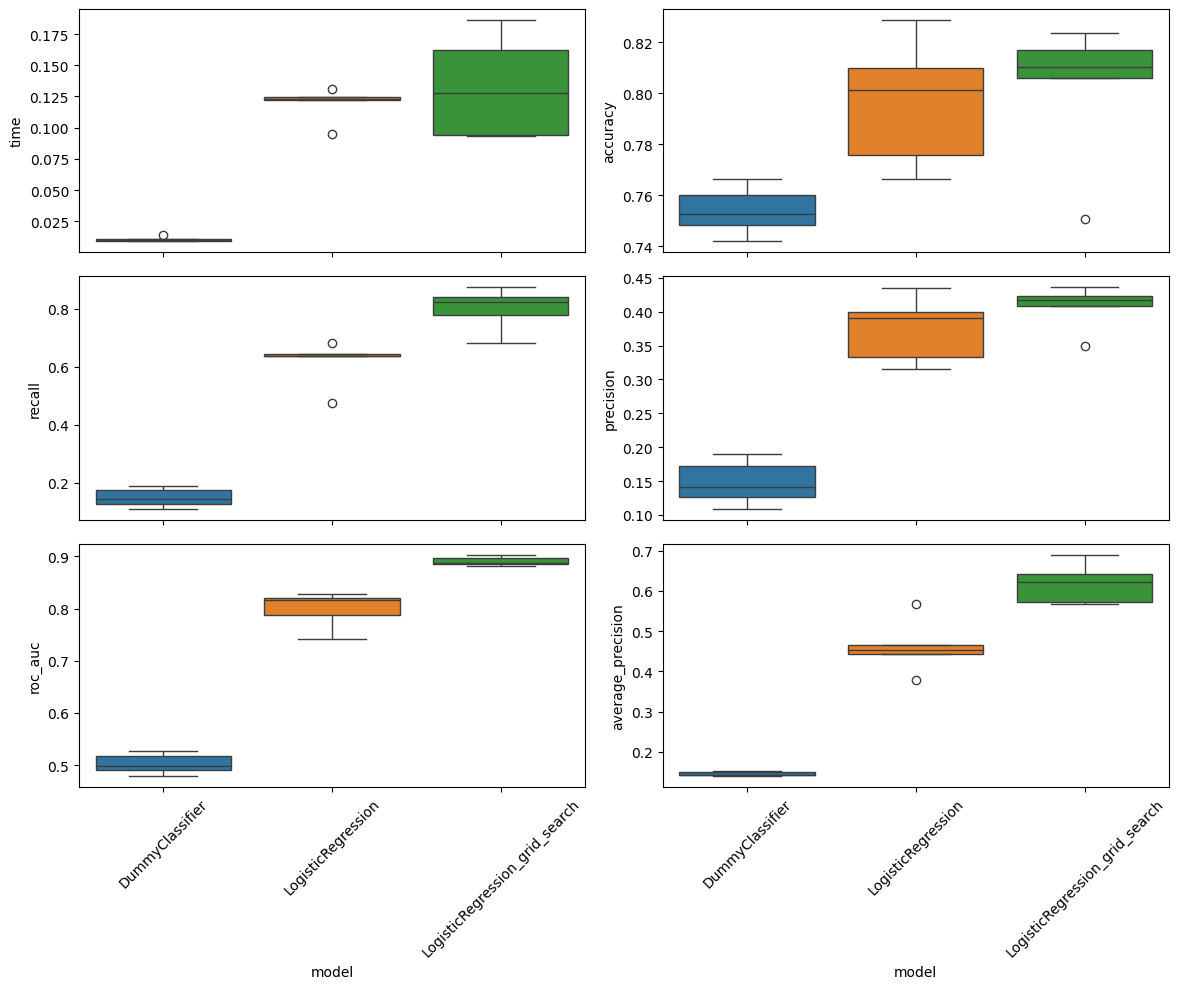

In [28]:
compare_metrics(df_results)

In [29]:
df_odds = pd.DataFrame(
    np.exp(grid_search.best_estimator_["clf"].coef_[0]),
    index=grid_search.best_estimator_[:-1].get_feature_names_out(),
    columns=["odds"]
)
df_odds.sort_values("odds")

,odds
min_max__Recency,0.046305
power__NumPurchasesTotal,0.085366
power__MntRegularProds,0.090997
ohe__hasChildren_1,0.477952
ohe__Teenhome_1,0.506419
ohe__AcceptedCmpTotal_1,0.727417
ohe__cluster_1,0.758319
power__MntGoldProds,0.867364
std__Income,0.942439
power__MntFruits,0.989129


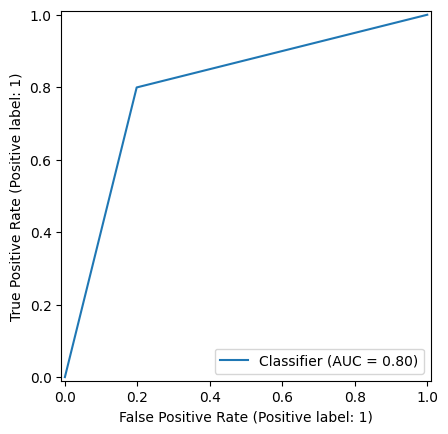

In [30]:
y_pred = cross_val_predict(
    grid_search.best_estimator_,
    X, y,
    cv=kf,
    n_jobs=-1
)

roc = RocCurveDisplay.from_predictions(y, y_pred)

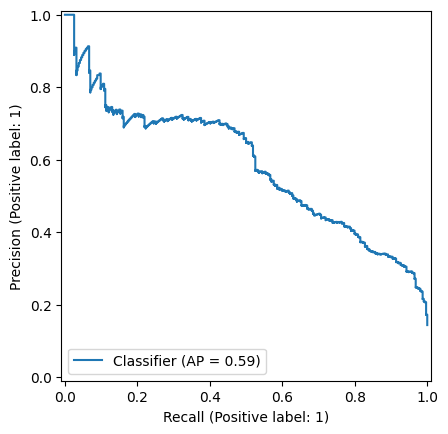

In [31]:
y_pred = cross_val_predict(
    grid_search.best_estimator_,
    X, y,
    cv=kf,
    n_jobs=-1,
    method="decision_function"
)

prc = PrecisionRecallDisplay.from_predictions(y, y_pred)

In [32]:
# Salvando o modelo
joblib.dump(
    grid_search.best_estimator_,
    FINAL_MODEL_FILEPATH
)

['/home/lucas/Documentos/python/ifood_analyst/models/logreg_preprocessing_undersampling.joblib']